<a href="https://colab.research.google.com/github/thuBv-123/Bai-tap-buoi-2/blob/main/Nhan%20dang%20hoa%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Nhận diện hoa

import os
import numpy as np
import matplotlib.pyplot as plt
from keras.utils import load_img, img_to_array, to_categorical
from keras.models import Sequential, load_model
from keras.layers import Dense, Flatten
from sklearn.model_selection import train_test_split


def load_images_and_labels(folder_path, target_size=(32,32)):
  imgs = []
  labels = []
  class_names=os.listdir(folder_path)
  class_label={name:i for i,name in enumerate(class_names)}
  for label in class_names:
    class_folder=os.path.join(folder_path,label)
    for filename in os.listdir(class_folder):
      file_path=os.path.join(class_folder,filename)
      try:
        img=load_img(file_path,target_size=target_size)
        img_array=img_to_array(img)/255.0
        imgs.append(img_array)
        labels.append(class_label[label])
      except:
        print(f"Lỗi khi xử lý ảnh: {file_path}")
  return np.array(imgs),to_categorical(labels),class_names


train_dir = '/content/drive/MyDrive/FLOWER_TRAIN'
val_dir = '/content/drive/MyDrive/FLOWER_TEST'

x_train, y_train, class_names = load_images_and_labels(train_dir)
x_val, y_val, _ = load_images_and_labels(val_dir)
x_train=x_train.reshape(len(x_train),32*32*3)u
x_train=x_train.astype('float32')/255
x_val=x_val.reshape(len(x_val),32*32*3)
x_val=x_val.astype('float32')/255


model = Sequential([
    Dense(3000,activation='relu',input_shape=(32*32*3,)),
    Dense(500,activation='relu'),
    Dense(len(class_names), activation='softmax')
])
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
history=model.fit(x_train, y_train, epochs=50, batch_size=64, validation_data=(x_val, y_val))





Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.2000 - loss: 1.6094 - val_accuracy: 0.1000 - val_loss: 1.6105
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.5333 - loss: 1.6006 - val_accuracy: 0.2000 - val_loss: 1.6124
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - accuracy: 0.5000 - loss: 1.5850 - val_accuracy: 0.2000 - val_loss: 1.6161
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.5667 - loss: 1.5629 - val_accuracy: 0.3000 - val_loss: 1.6229
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.7000 - loss: 1.5331 - val_accuracy: 0.2000 - val_loss: 1.6337
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.8333 - loss: 1.4938 - val_accuracy: 0.1000 - val_loss: 1.6496
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - accuracy: 0.8333 - loss: 1.4446 - val_accuracy: 0.1000 - val_loss: 1.6723
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.8667 - loss: 1.3848 - val_accuracy: 0.1000 - val_loss: 1.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


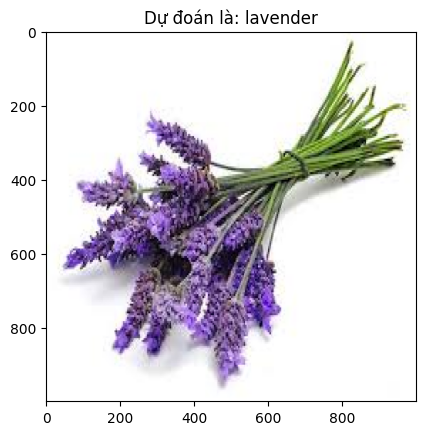

In [ ]:
img = load_img('/content/2.jpg', target_size=(1000, 1000))

plt.imshow(img)

img_array = img_to_array(img.resize((32, 32))) / 255


img_array = img_to_array(img_array)
img_flat = img_array.reshape(1, -1)
prediction = model.predict(img_flat)
predicted_class = class_names[np.argmax(prediction)]

plt.title(f'Hoa này là: {predicted_class}')
plt.show()